# Iris Flower Classification
### Multi-class Classification using Scikit-learn

**Goal:** Predict the species of an Iris flower (Setosa, Versicolor, Virginica)
based on its sepal and petal measurements.

**Tools Used:** Python, NumPy, Pandas, Scikit-learn, Matplotlib

**Models:** Logistic Regression, K-Nearest Neighbors (KNN)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

In [2]:
# Loading the Iris dataset
iris = load_iris()

# Converting to DataFrame for easy viewing
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("Dataset Shape:", df.shape)
print("\n First 5 rows:")
print(df.head())
print("\n Class Distribution:")
print(df['species_name'].value_counts())
print("\n Basic Statistics:")
print(df.describe().round(2))

Dataset Shape: (150, 6)

 First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa  

 Class Distribution:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

 Basic Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
st

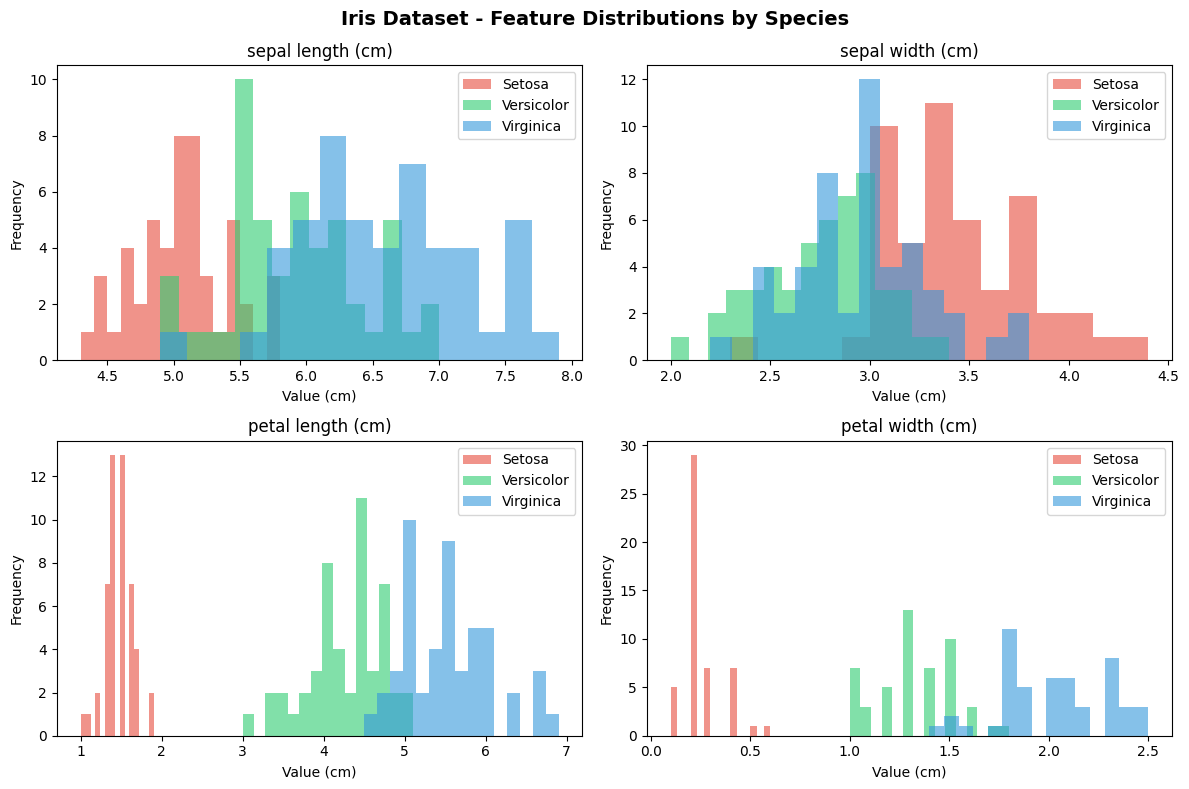

Feature distribution plot saved!


In [3]:

# Visualizig Feature Distribution

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Iris Dataset - Feature Distributions by Species', fontsize=14, fontweight='bold')

features = iris.feature_names
colors = ['#e74c3c', '#2ecc71', '#3498db']
species_names = ['Setosa', 'Versicolor', 'Virginica']

for idx, (ax, feature) in enumerate(zip(axes.flatten(), features)):
    for species_idx, (color, name) in enumerate(zip(colors, species_names)):
        data = df[df['species'] == species_idx][feature]
        ax.hist(data, alpha=0.6, color=color, label=name, bins=15)
    ax.set_title(feature)
    ax.set_xlabel('Value (cm)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature distribution plot saved!")

In [4]:

# Data Preprocessing & Train-Test Split


# Features and target
X = iris.data
y = iris.target

# Spliting: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print("\n Features have been normalized using StandardScaler")

Training samples : 120
Testing samples  : 30
Features         : 4

 Features have been normalized using StandardScaler


In [6]:

# Training Models — Logistic Regression and KNN


# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_preds)

# Model 2: K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_preds)

print("=" * 45)
print(f"  Logistic Regression Accuracy : {lr_accuracy*100:.2f}%")
print(f"  KNN Accuracy                 : {knn_accuracy*100:.2f}%")
print("=" * 45)
print(f"\n Best Model: {'Logistic Regression' if lr_accuracy >= knn_accuracy else 'KNN'}")

  Logistic Regression Accuracy : 93.33%
  KNN Accuracy                 : 93.33%

 Best Model: Logistic Regression


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LOGISTIC REGRESSION — Classification Report
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KNN — Classification Report
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg 

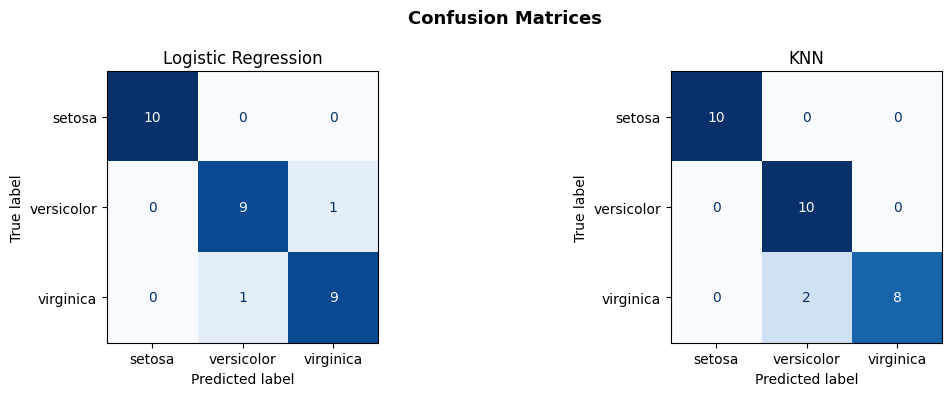

 Confusion matrix saved!


In [7]:

# Performance Evaluation

print("━" * 50)
print("  LOGISTIC REGRESSION — Classification Report")
print("━" * 50)
print(classification_report(y_test, lr_preds,
      target_names=iris.target_names))

print("━" * 50)
print("  KNN — Classification Report")
print("━" * 50)
print(classification_report(y_test, knn_preds,
      target_names=iris.target_names))

# Confusion Matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')

for ax, preds, title in zip(axes,
                             [lr_preds, knn_preds],
                             ['Logistic Regression', 'KNN']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved!")

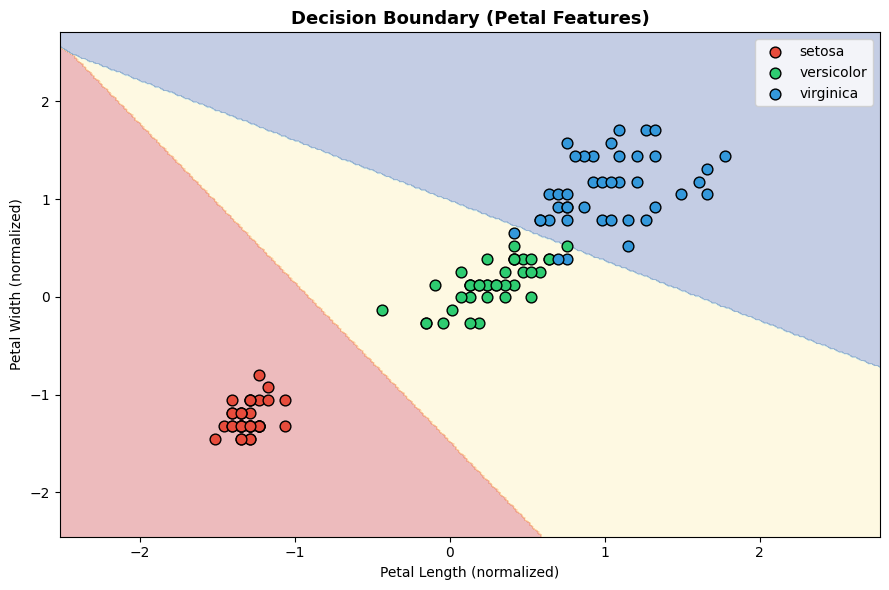

Decision boundary plot saved!


In [8]:

# Decision Boundary Visualization


# Use only 2 features for 2D plot (petal length & petal width)
X_2d = X_train_scaled[:, 2:]
X_2d_test = X_test_scaled[:, 2:]

best_model = lr_model if lr_accuracy >= knn_accuracy else knn_model
best_model_2d = LogisticRegression(max_iter=200, random_state=42) if lr_accuracy >= knn_accuracy else KNeighborsClassifier(n_neighbors=5)
best_model_2d.fit(X_2d, y_train)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = best_model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')

colors = ['#e74c3c', '#2ecc71', '#3498db']
for i, (color, name) in enumerate(zip(colors, iris.target_names)):
    mask = y_train == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=name, edgecolors='k', s=60)

plt.title('Decision Boundary (Petal Features)', fontsize=13, fontweight='bold')
plt.xlabel('Petal Length (normalized)')
plt.ylabel('Petal Width (normalized)')
plt.legend()
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decision boundary plot saved!")

In [9]:
# Summary


print("=" * 50)
print(" PROJECT SUMMARY — IRIS CLASSIFICATION")
print("=" * 50)
print(f"  Dataset        : Iris (150 samples, 4 features)")
print(f"  Train/Test     : 120 / 30 samples")
print(f"  Preprocessing  : StandardScaler normalization")
print(f"  LR Accuracy    : {lr_accuracy*100:.2f}%")
print(f"  KNN Accuracy   : {knn_accuracy*100:.2f}%")
print(f"  Best Model     : {'Logistic Regression' if lr_accuracy >= knn_accuracy else 'KNN'}")
print("=" * 50)

 PROJECT SUMMARY — IRIS CLASSIFICATION
  Dataset        : Iris (150 samples, 4 features)
  Train/Test     : 120 / 30 samples
  Preprocessing  : StandardScaler normalization
  LR Accuracy    : 93.33%
  KNN Accuracy   : 93.33%
  Best Model     : Logistic Regression
